In [9]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [11]:
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-19-control-cheetah-velocity-probe",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-19-control-cheetah-velocity-probe: 100%|██████████| 756/756 [00:00<00:00, 3564.61it/s]


Found 756 configurations
Found 756 configurations


100%|██████████| 756/756 [00:23<00:00, 31.57it/s]


In [12]:
df = df[df['seed'] == 1]
df = df[df['config_start_step'] == 75]
df.shape

(126, 25)

In [15]:
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())

positions = obs[:, :8]  # qpos[1:]
velocities = obs[:, 8:]  # qvel[:]  -> 9 dims
vel_torso = velocities[:, 0][:, None]

z.shape, obs.shape, actions.shape, positions.shape, velocities.shape, vel_torso.shape


((63000, 512), (63000, 17), (63000, 6), (63000, 8), (63000, 9), (63000, 1))

In [16]:
df['avg_vel_torso'] = df['observations'].apply(
    lambda x: np.array(x)[:, 8].mean())

df['n_steps_upside_down'] = df['observations'].apply(
    lambda x: np.sum(np.cos(np.array(x)[:, 1]) < -.5))

# torso_pitch = obs[:, 1]  # qpos[1]
# upside_down = np.cos(torso_pitch) < 0

# plt.plot(upside_down)

# # df['upside_down'] = upside_down

In [18]:
# plt.plot(np.cos(torso_pitch)[:1000])
# plt.plot(np.cos(torso_pitch)[:1000] < -.5)

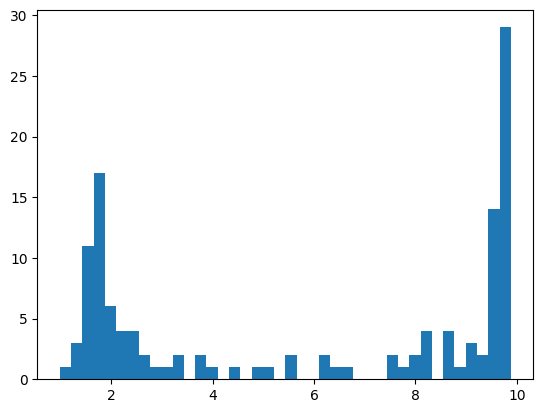

In [19]:
plt.hist(df['avg_vel_torso'], bins=40)
plt.show()

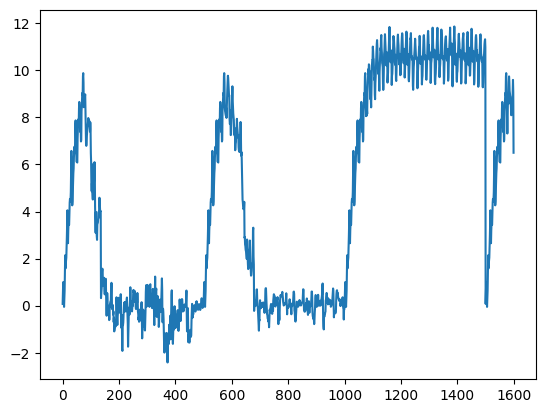

In [20]:
plt.plot(vel_torso[:1600])

In [ ]:
df['config_direction_str'].unique()

array(['x_t+20', 'delta_40', 'delta_10', 'x_t+5', 'x_t+10', 'delta_20',
       'random_0', 'delta_30', 'x_t+30', 'x_t+0', 'random_1', 'delta_5',
       'x_t+40'], dtype=object)

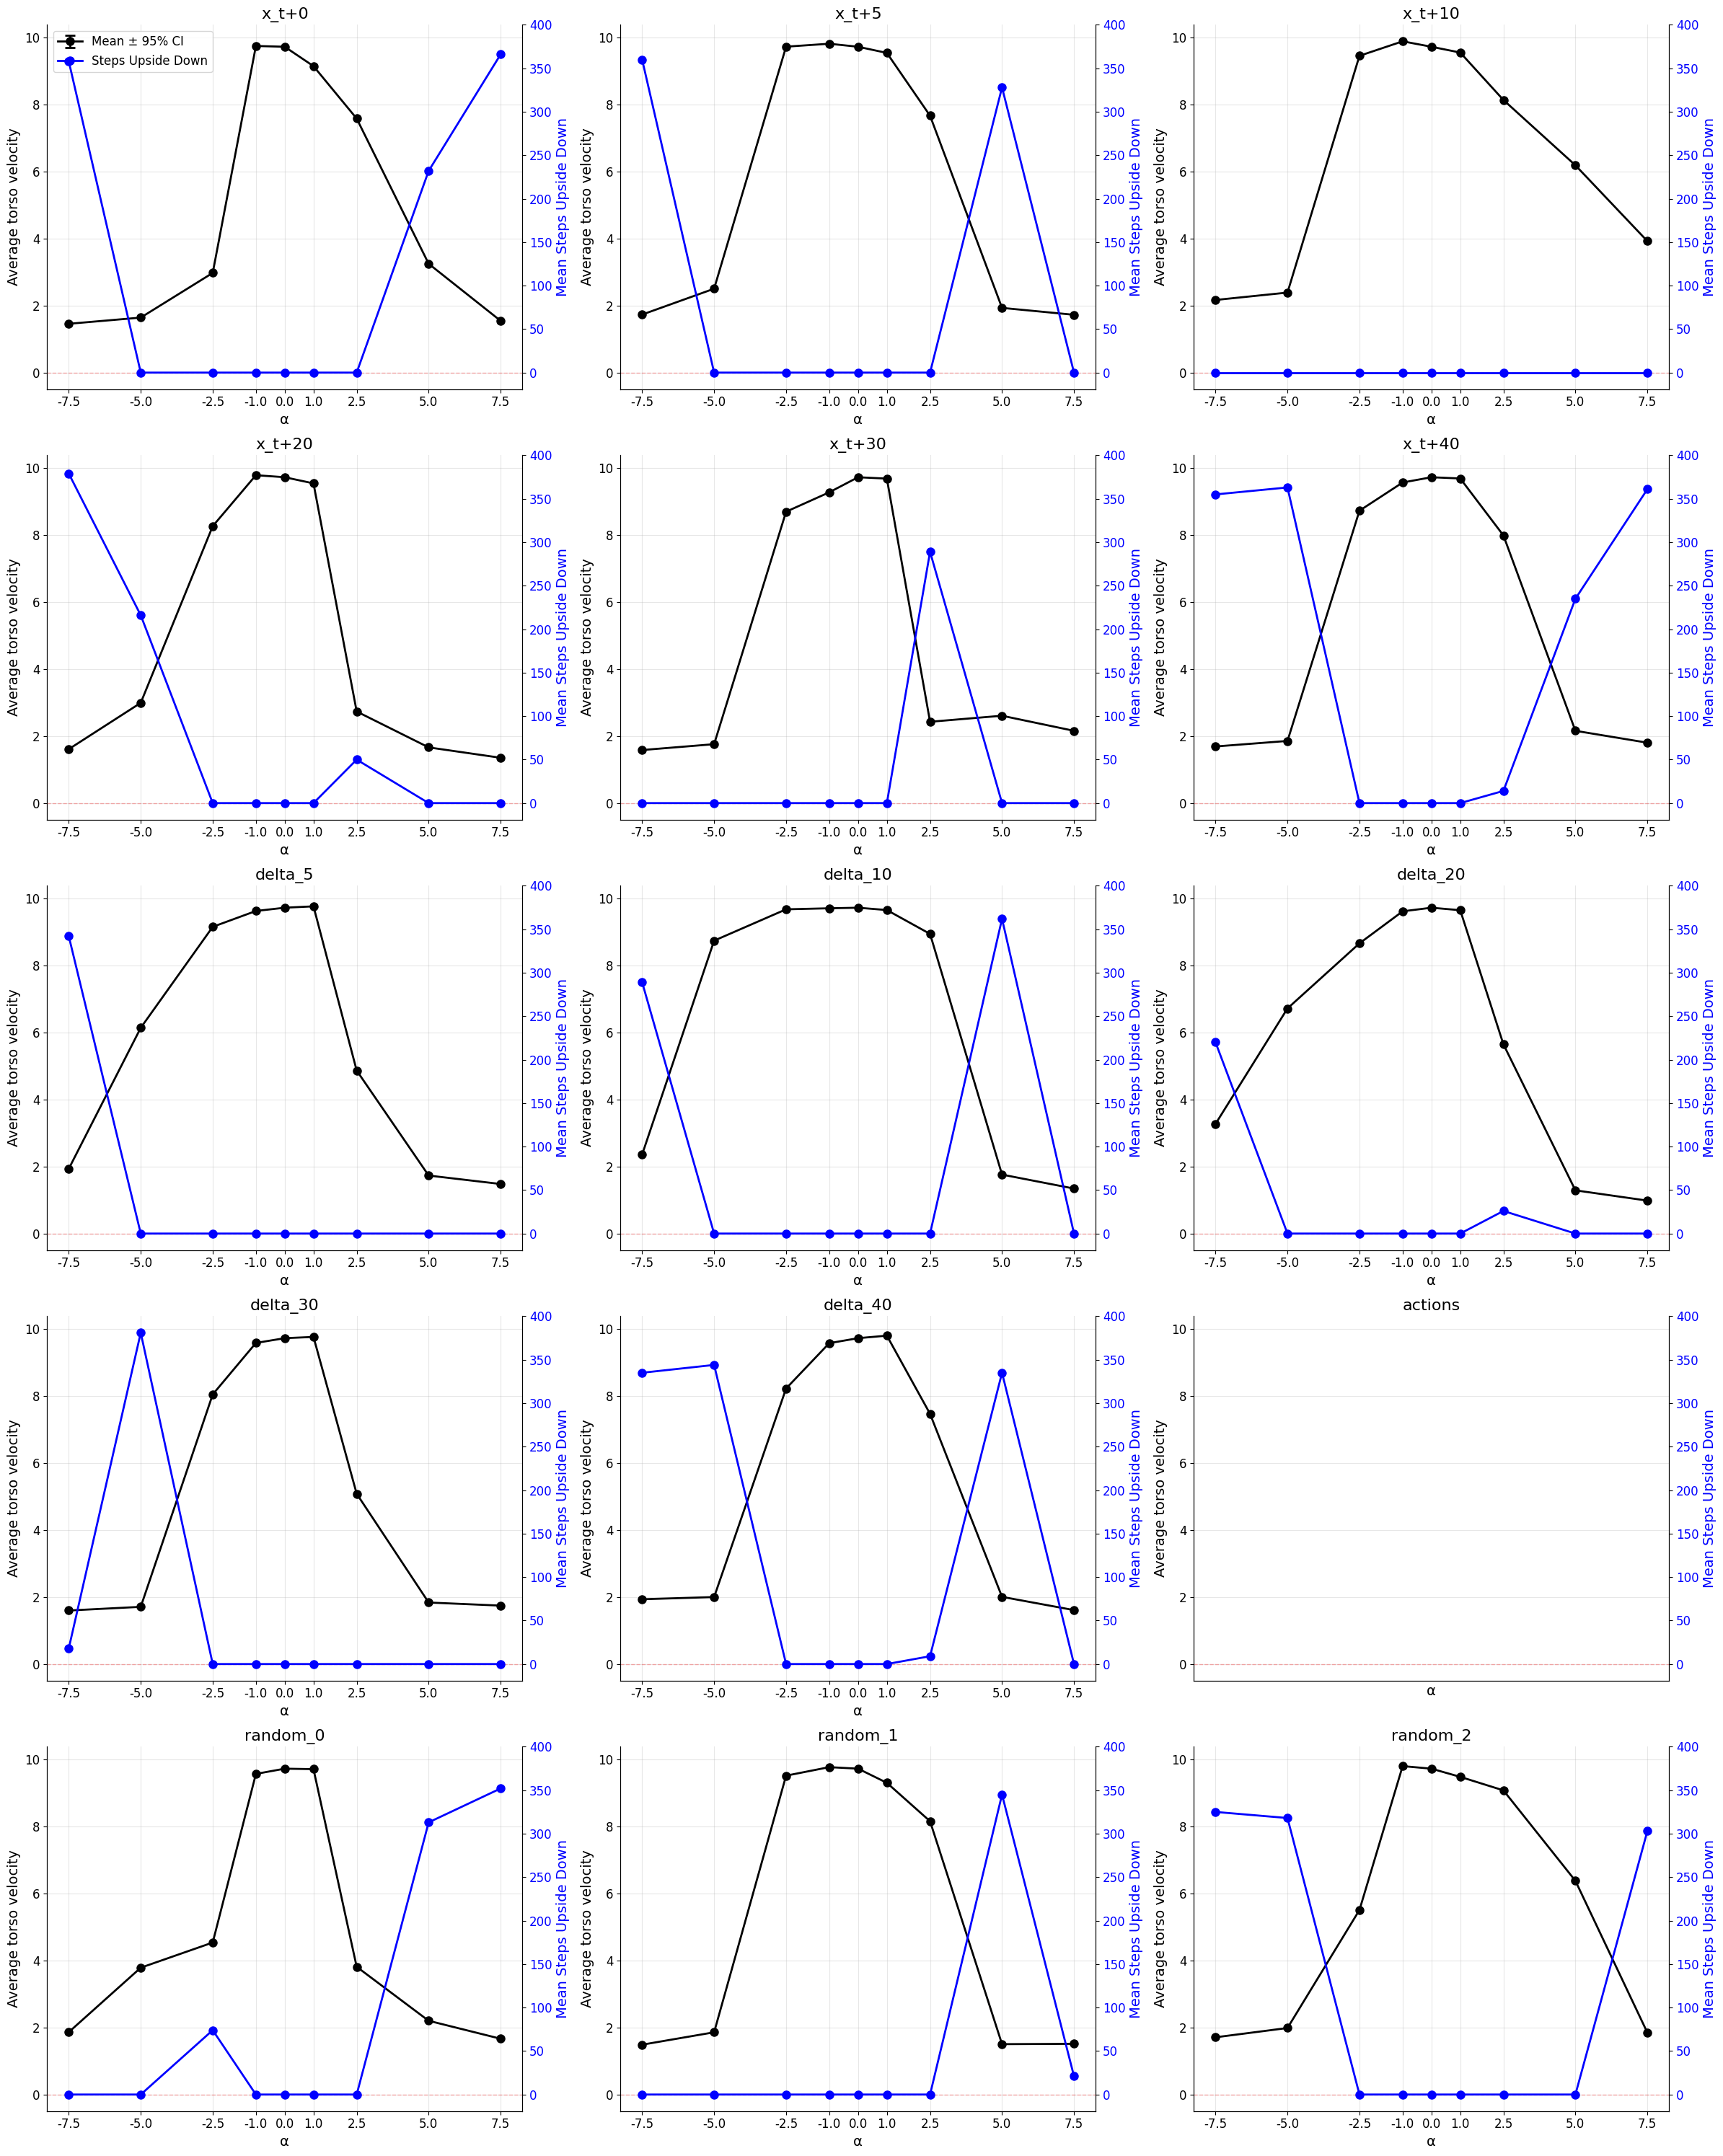

In [8]:
# Get unique direction strings

direction_order = ['random_0', 'random_1', 'random_2']
direction_order = [
    'x_t+0', 'x_t+5', 'x_t+10', 'x_t+20', 'x_t+30', 'x_t+40', 'delta_5',
    'delta_10', 'delta_20', 'delta_30', 'delta_40', 'actions', 'random_0',
    'random_1', 'random_2'
]
direction_strs = direction_order
n_directions = len(direction_strs)
y_var = 'avg_vel_torso'

# Create subplots: 3 columns, calculate rows needed
n_cols = 3
n_rows = (n_directions + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = axes.flatten() if n_directions > 1 else [axes]

for idx, direction_str in enumerate(direction_strs):
    ax1 = axes[idx]

    df_to_plot = df[df['config_direction_str'] == direction_str]

    # Group by alpha
    grouped = df_to_plot.groupby('config_magnitude')

    # Left y-axis:
    ax1.set_xlabel('α', fontsize=14)
    ax1.set_ylabel('Average torso velocity', fontsize=14)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # Plot one line per seed
    for seed in df_to_plot['config_seed'].unique():
        seed_data = df_to_plot[df_to_plot['config_seed'] == seed].sort_values(
            'config_magnitude')
        ax1.plot(seed_data['config_magnitude'],
                 seed_data[y_var],
                 color='pink',
                 marker='o',
                 alpha=0.5,
                 linewidth=1)

    # Plot mean with error bars (95% CI)
    alphas = []
    means = []
    ci_lower = []
    ci_upper = []

    for alpha, group in grouped:
        alphas.append(alpha)
        mean_val = group[y_var].mean()
        means.append(mean_val)
        std_val = group[y_var].std()
        n = len(group)
        ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
        ci_lower.append(mean_val - ci)
        ci_upper.append(mean_val + ci)

    ax1.errorbar(alphas,
                 means,
                 yerr=[
                     np.array(means) - np.array(ci_lower),
                     np.array(ci_upper) - np.array(means)
                 ],
                 fmt='o-',
                 color='black',
                 linewidth=2,
                 markersize=8,
                 capsize=5,
                 capthick=2,
                 label='Mean ± 95% CI')

    ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.set_xticks(alphas)
    ax1.set_xticklabels([str(a) for a in alphas])
    ax1.grid(True, alpha=0.3)
    #ax1.set_ylim(-1.75, 1.75)

    # Right y-axis: number of steps upside down
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Steps Upside Down', fontsize=14, color='blue')

    # Calculate mean steps upside down for each alpha
    upside_down_means = []
    for alpha, group in grouped:
        upside_down_mean = group['n_steps_upside_down'].mean()
        upside_down_means.append(upside_down_mean)

    ax2.plot(alphas,
             upside_down_means,
             'o-',
             color='blue',
             linewidth=2,
             markersize=8,
             label='Steps Upside Down')
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)

    # Title
    ax1.set_title(direction_str, fontsize=16)

    # Legend (only for first plot)
    if idx == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2,
                   labels1 + labels2,
                   loc='upper left',
                   fontsize=12)

# Share y-axes across all subplots
# Get the y-limits from all left axes
all_y_mins = []
all_y_maxs = []
for idx in range(n_directions):
    y_min, y_max = axes[idx].get_ylim()
    all_y_mins.append(y_min)
    all_y_maxs.append(y_max)

# Set the same y-limits for all left axes
global_y_min = min(all_y_mins)
global_y_max = max(all_y_maxs)
for idx in range(n_directions):
    axes[idx].set_ylim(global_y_min, global_y_max)

# Get the y-limits from all right axes
all_y2_mins = []
all_y2_maxs = []
for idx in range(n_directions):
    # Get the twin axis
    ax2 = axes[idx].get_shared_x_axes().get_siblings(axes[idx])
    # Actually, we need to access the twinx axes differently
    for ax in axes[idx].figure.axes:
        if ax.bbox.bounds == axes[idx].bbox.bounds and ax != axes[idx]:
            y_min, y_max = ax.get_ylim()
            all_y2_mins.append(y_min)
            all_y2_maxs.append(y_max)
            break

# Set the same y-limits for all right axes
if all_y2_mins and all_y2_maxs:
    global_y2_min = min(all_y2_mins)
    global_y2_max = max(all_y2_maxs)
    for idx in range(n_directions):
        for ax in axes[idx].figure.axes:
            if ax.bbox.bounds == axes[idx].bbox.bounds and ax != axes[idx]:
                ax.set_ylim(global_y2_min, global_y2_max)
                break

# Hide any unused subplots
for idx in range(n_directions, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()


In [38]:
direction_str = 'delta_30'
df_to_plot = df[(df['config_direction_str'] == direction_str) &
                (df['config_magnitude'] == -2.5)]
obs = np.array(df_to_plot['observations'].iloc[0])

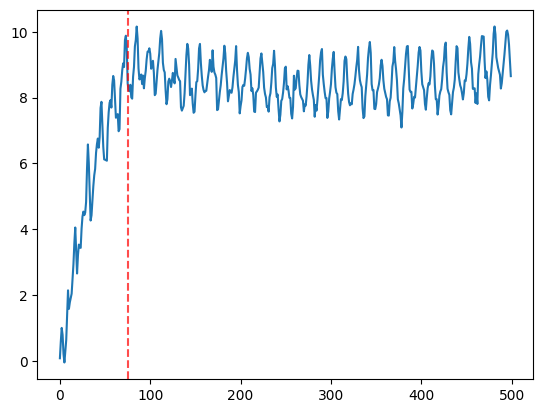

In [39]:
vel_torso = obs[:, 8]
plt.plot(vel_torso)
plt.axvline(x=75, color='red', linestyle='--', alpha=0.7)
